# Pass 2: testing the LightGBM ranker as it's built

Scratch notebook for trying out Pass 2 pieces as they land, starting with the interface refactor (`rank_fn`/`optimiser_fn`) and the LightGBM training panel builder. This notebook will grow as `rank_by_lgbm` (the actual fit/predict step) and later Pass 2 items get built — it's not part of the pipeline itself, just a place to poke at things.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import ingest, features
from src.models import ranker, lgbm_ranker
from src.portfolio import backtest

## 1. Pull data (cached after the first run)

In [2]:
prices_long = ingest.load_or_fetch_prices(
    config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER], config.DATA_START_DATE, config.DATA_END_DATE
)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)
prices = ingest.to_wide_adj_close(prices_long)
universe_prices = prices[config.TICKER_UNIVERSE]
print("prices (wide):", prices.shape)

prices (wide): (3932, 40)


## 2. The refactored `rank_fn` / `optimiser_fn` interface

`backtest.py`'s pluggable ranking rule used to be `score_fn(momentum, low_volatility, dividend_yield)` — three already-computed factor snapshots in, scores out. That doesn't work for a model that needs to build its own training panel across many dates (like LightGBM), so it broadened to `rank_fn(universe_prices, dividends, as_of_date)` — raw data in, scores out. `ranker.rank_by_composite_score` and `ranker.rank_by_momentum_only` are thin adapters that compute the three factors internally and delegate to the original `score_stocks`/`score_by_momentum_only`, so nothing about the composite/momentum-only strategies actually changed — just how they plug in.

In [3]:
as_of_date = pd.Timestamp("2023-01-03")

composite_scores = ranker.rank_by_composite_score(universe_prices, dividends, as_of_date)
momentum_scores = ranker.rank_by_momentum_only(universe_prices, dividends, as_of_date)

print("Top 5, composite score:")
print(composite_scores.sort_values(ascending=False).head())
print("\nTop 5, momentum-only:")
print(momentum_scores.sort_values(ascending=False).head())

Top 5, composite score:
ticker
T      1.232693
XOM    0.963359
VZ     0.936071
MRK    0.883425
COP    0.849283
dtype: float64

Top 5, momentum-only:
ticker
XOM     2.702534
COP     2.475883
CVX     1.962992
MRK     1.618386
ABBV    0.920853
dtype: float64


In [4]:
# Confirm run_backtest still works through the new interface and reproduces
# the same numbers already seen in notebook 1 (default rank_fn/optimiser_fn
# match the old score_fn defaults exactly).
daily_returns, _ = backtest.run_backtest(prices, dividends)
print("composite strategy_net final growth:", (1 + daily_returns["strategy_net"]).cumprod().iloc[-1])

composite strategy_net final growth: 3.6641662891864324


## 3. `features.training_window`'s `extra_months`

The LightGBM panel needs a *wider* window than a single as-of-date query: its earliest training snapshot needs its own 12-month momentum lookback before the window even starts. `extra_months` widens the window's start without moving its end.

In [5]:
standard_window = features.training_window(universe_prices, as_of_date)
widened_window = features.training_window(universe_prices, as_of_date, extra_months=config.MOMENTUM_LOOKBACK_MONTHS)

print("standard window:", standard_window.index.min().date(), "to", standard_window.index.max().date())
print("widened window: ", widened_window.index.min().date(), "to", widened_window.index.max().date())
print("same end date:", standard_window.index.max() == widened_window.index.max())

standard window: 2020-01-03 to 2022-12-30
widened window:  2019-01-03 to 2022-12-30
same end date: True


## 4. The LightGBM training panel

One row per ticker per historical monthly snapshot: the three factors as of that snapshot date, plus the *realised* forward 1-month return (the label). This is what `rank_by_lgbm` will fit a model on — built here directly to inspect it before that step exists.

In [6]:
panel = lgbm_ranker._build_training_panel(universe_prices, dividends, as_of_date)

print("panel shape:", panel.shape)
print("snapshot dates:", panel["snapshot_date"].nunique(), "-", panel["snapshot_date"].min().date(), "to", panel["snapshot_date"].max().date())
print("tickers:", panel["ticker"].nunique())
panel.head()

panel shape: (1365, 6)
snapshot dates: 35 - 2020-01-31 to 2022-11-30
tickers: 39


,momentum,low_volatility,dividend_yield,forward_return,ticker,snapshot_date
0,0.790808,0.014480,0.009752,-0.114701,AAPL,2020-01-31
1,0.532431,0.011752,0.011594,-0.045688,MSFT,2020-01-31
2,0.189628,0.014277,0.000000,-0.065279,GOOGL,2020-01-31
3,0.075119,0.013000,0.000000,-0.062214,AMZN,2020-01-31
4,0.231327,0.015843,0.000000,-0.046754,META,2020-01-31


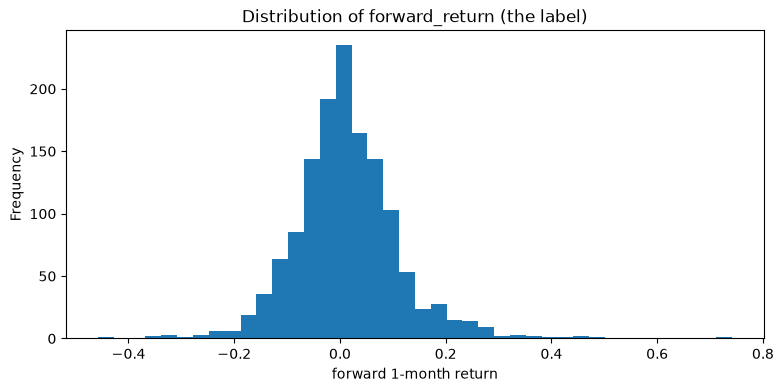

count    1365.000000
mean        0.012207
std         0.099147
min        -0.457890
25%        -0.043609
50%         0.007340
75%         0.064469
max         0.741452
Name: forward_return, dtype: float64

In [7]:
panel["forward_return"].plot.hist(bins=40, figsize=(9, 4), title="Distribution of forward_return (the label)")
plt.xlabel("forward 1-month return")
plt.show()
panel["forward_return"].describe()

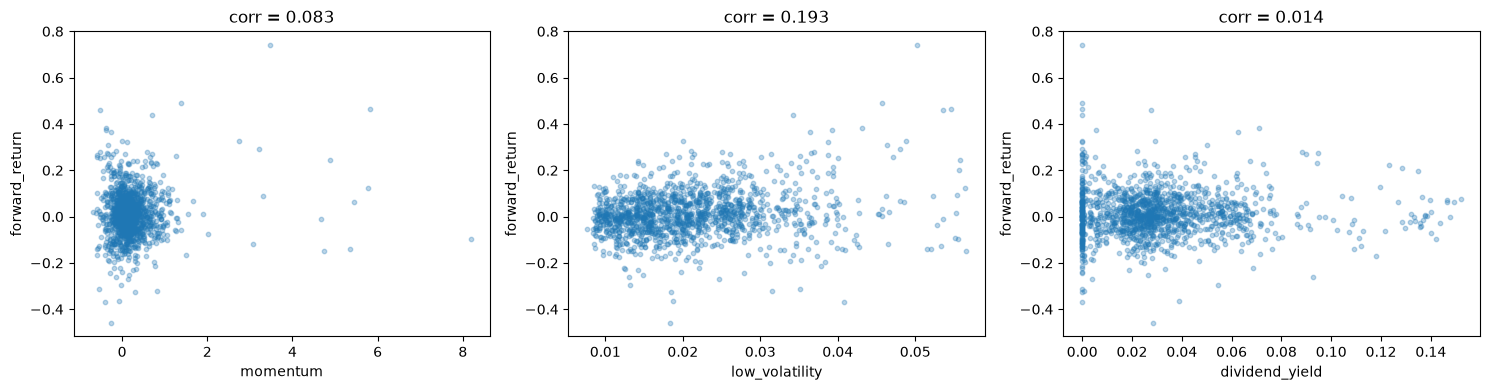

In [8]:
# Is there any visible relationship between a feature and what actually happened
# next? Weak/noisy is expected and normal for a single factor at the individual
# stock-month level — this is just an eyeball check, not a rigorous signal test.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature_name in zip(axes, ["momentum", "low_volatility", "dividend_yield"]):
    ax.scatter(panel[feature_name], panel["forward_return"], alpha=0.3, s=10)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("forward_return")
    correlation = panel[feature_name].corr(panel["forward_return"])
    ax.set_title(f"corr = {correlation:.3f}")
plt.tight_layout()
plt.show()

## 5. Full walk-forward comparison: LightGBM vs composite vs momentum-only vs equal-weight vs SPY

`rank_by_lgbm` now exists — run it through the exact same walk-forward backtest as everything else (rolling training window, transaction costs, both benchmarks) and see how it actually performs, not just what it predicts at one snapshot.

In [9]:
from src.risk import metrics

composite_returns, composite_log = backtest.run_backtest(prices, dividends)
momentum_returns, momentum_log = backtest.run_backtest(prices, dividends, rank_fn=ranker.rank_by_momentum_only)
lgbm_returns, lgbm_log = backtest.run_backtest(prices, dividends, rank_fn=lgbm_ranker.rank_by_lgbm)

print("rebalances:", len(lgbm_log))
print("LightGBM strategy_net final growth:", (1 + lgbm_returns["strategy_net"]).cumprod().iloc[-1])

rebalances: 139
LightGBM strategy_net final growth: 5.438999945714136


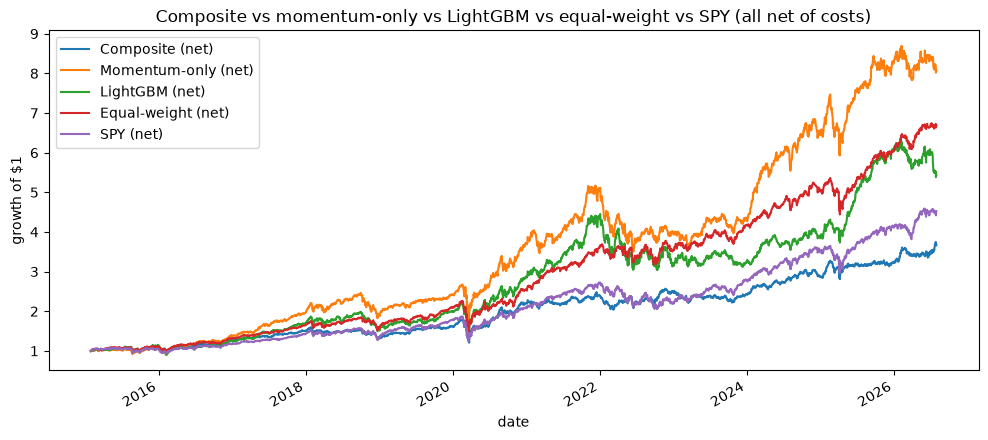

In [10]:
five_way = pd.DataFrame(
    {
        "Composite (net)": composite_returns["strategy_net"],
        "Momentum-only (net)": momentum_returns["strategy_net"],
        "LightGBM (net)": lgbm_returns["strategy_net"],
        "Equal-weight (net)": composite_returns["equal_weight_net"],
        "SPY (net)": composite_returns["sp500_net"],
    }
)
(1 + five_way).cumprod().plot(
    figsize=(12, 5), title="Composite vs momentum-only vs LightGBM vs equal-weight vs SPY (all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

In [11]:
five_way_comparison = pd.DataFrame(
    {
        "composite": metrics.compute_all(composite_returns["strategy_net"]),
        "momentum_only": metrics.compute_all(momentum_returns["strategy_net"]),
        "lightgbm": metrics.compute_all(lgbm_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(composite_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(composite_returns["sp500_net"]),
    }
)
five_way_comparison

,composite,momentum_only,lightgbm,equal_weight,SPY
sharpe_ratio,0.651551,0.912273,0.731681,0.970819,0.721705
sortino_ratio,0.814359,1.138343,0.920473,1.151409,0.883017
max_drawdown,-0.327716,-0.328220,-0.319929,-0.342343,-0.337173
historical_var_95,-0.014192,-0.019668,-0.020100,-0.014389,-0.016559
monte_carlo_var_95,-0.016753,-0.020231,-0.020693,-0.016563,-0.017994
expected_shortfall_95,-0.023456,-0.030118,-0.031406,-0.024643,-0.026818
var_breaches_95,145.000000,145.000000,145.000000,145.000000,145.000000
historical_var_99,-0.026761,-0.032193,-0.037901,-0.028167,-0.031695
monte_carlo_var_99,-0.023965,-0.029022,-0.029621,-0.023783,-0.025759
expected_shortfall_99,-0.043815,-0.050280,-0.051078,-0.045058,-0.046305


### Headline returns

Total and annualised (CAGR) return, net of costs — the plain-English bottom line before the risk-adjusted metrics above.

In [12]:
n_years = (five_way.index[-1] - five_way.index[0]).days / 365.25

headline_returns = pd.DataFrame(
    {
        name: {
            "total_return_%": ((1 + returns).cumprod().iloc[-1] - 1) * 100,
            "annualised_return_%": ((1 + returns).cumprod().iloc[-1] ** (1 / n_years) - 1) * 100,
        }
        for name, returns in five_way.items()
    }
).T
headline_returns.round(1)

,total_return_%,annualised_return_%
Composite (net),266.4,12.0
Momentum-only (net),706.7,19.9
LightGBM (net),443.9,15.9
Equal-weight (net),568.1,18.0
SPY (net),352.5,14.0


### Main holdings: composite vs momentum-only vs LightGBM

Weights, not just ticker names, at the most recent rebalance.

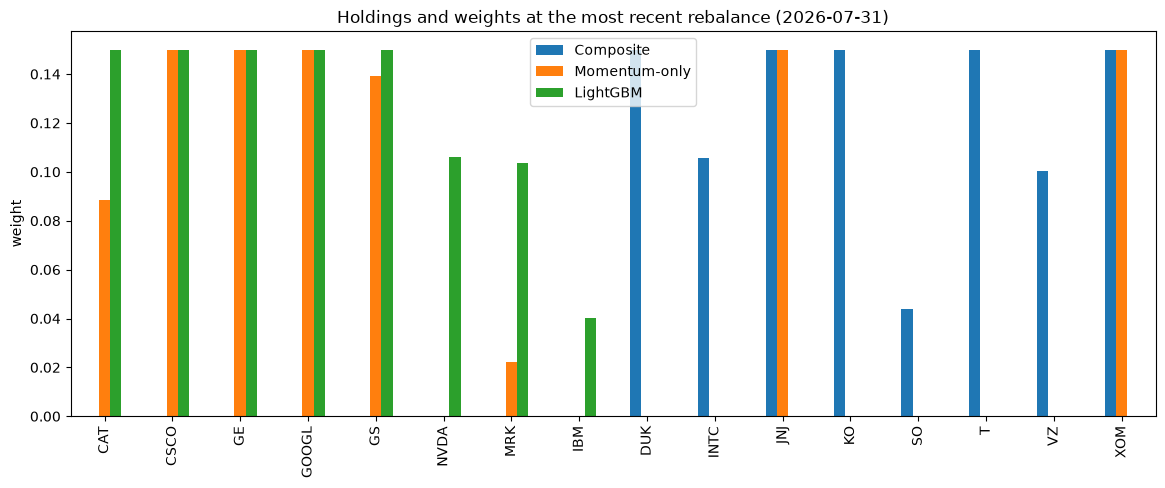

,Composite,Momentum-only,LightGBM
CAT,,0.089,0.15
CSCO,,0.15,0.15
GE,,0.15,0.15
GOOGL,,0.15,0.15
GS,,0.139,0.15
NVDA,,,0.106
MRK,,0.022,0.103
IBM,,,0.04
DUK,0.15,,
INTC,0.106,,


In [13]:
latest_weights = pd.DataFrame(
    {
        "Composite": pd.Series(composite_log["weights"].iloc[-1]),
        "Momentum-only": pd.Series(momentum_log["weights"].iloc[-1]),
        "LightGBM": pd.Series(lgbm_log["weights"].iloc[-1]),
    }
).fillna(0.0)
latest_weights = latest_weights[(latest_weights > 0).any(axis=1)].sort_values("LightGBM", ascending=False)

latest_weights.plot.bar(
    figsize=(14, 5), title=f"Holdings and weights at the most recent rebalance ({lgbm_log.index[-1].date()})"
)
plt.ylabel("weight")
plt.show()
latest_weights.round(3).replace(0, "")

### Most persistent holdings across the whole backtest

A single snapshot doesn't show which names each strategy *consistently* favours — this sums each ticker's weight across all 90 rebalances, so the biggest numbers are the stocks that were held often and heavily, not just picked once.

In [14]:
def total_weight_by_ticker(rebalance_log: pd.DataFrame) -> pd.Series:
    weights_over_time = pd.DataFrame(list(rebalance_log["weights"]), index=rebalance_log.index).fillna(0.0)
    return weights_over_time.sum()


total_weights = pd.DataFrame(
    {
        "Composite": total_weight_by_ticker(composite_log),
        "Momentum-only": total_weight_by_ticker(momentum_log),
        "LightGBM": total_weight_by_ticker(lgbm_log),
    }
).fillna(0.0)

# Union of each strategy's own top 10, so names distinctive to just one
# strategy still show up rather than being crowded out by another's favourites.
top_10_union = set()
for column in total_weights.columns:
    top_10_union.update(total_weights[column].sort_values(ascending=False).head(10).index)

total_weights.loc[sorted(top_10_union)].sort_values("LightGBM", ascending=False)

,Composite,Momentum-only,LightGBM
NVDA,1.95000,13.05572,13.87488
TSLA,1.95000,4.37748,7.59555
AAPL,1.81617,5.53254,7.50887
AMZN,1.20000,7.26282,7.44481
GOOGL,0.45000,3.96660,6.65334
UNH,2.70000,9.04594,6.23923
BA,2.34159,4.91421,5.83320
MSFT,1.35000,7.57300,5.65779
HD,5.12210,5.68734,5.04906
CAT,1.84717,3.65084,5.02588


## 6. Feature importance: what did LightGBM actually rely on?

Gradient-boosted trees are more explainable than most ML models precisely because of this: **gain** (how much a feature's splits actually reduced prediction error, summed across every tree) tells us what mattered, not just what was used. **Split count** (how often a feature was used at all) is a simpler, less informative complement — a feature can be split on often while contributing little each time.

First: a single snapshot, at the most recent rebalance.

In [15]:
latest_rebalance_date = lgbm_log.index[-1]
latest_panel = lgbm_ranker._build_training_panel(universe_prices, dividends, latest_rebalance_date)
latest_model = lgbm_ranker._fit_model(latest_panel)

snapshot_importance = pd.DataFrame(
    {
        "split_count": latest_model.booster_.feature_importance(importance_type="split"),
        "total_gain": latest_model.booster_.feature_importance(importance_type="gain"),
    },
    index=lgbm_ranker._FEATURE_COLUMNS,
)
snapshot_importance["gain_%"] = (snapshot_importance["total_gain"] / snapshot_importance["total_gain"].sum() * 100).round(1)
snapshot_importance

,split_count,total_gain,gain_%
momentum,103,3.338563,44.9
low_volatility,111,3.774813,50.8
dividend_yield,16,0.318878,4.3


A single snapshot could just be idiosyncratic to that one month's training data. More convincing: refit at every one of the 90 rebalance dates already in `lgbm_log` and average the gain share across all of them — does the same feature dominate consistently, or does it vary a lot month to month?

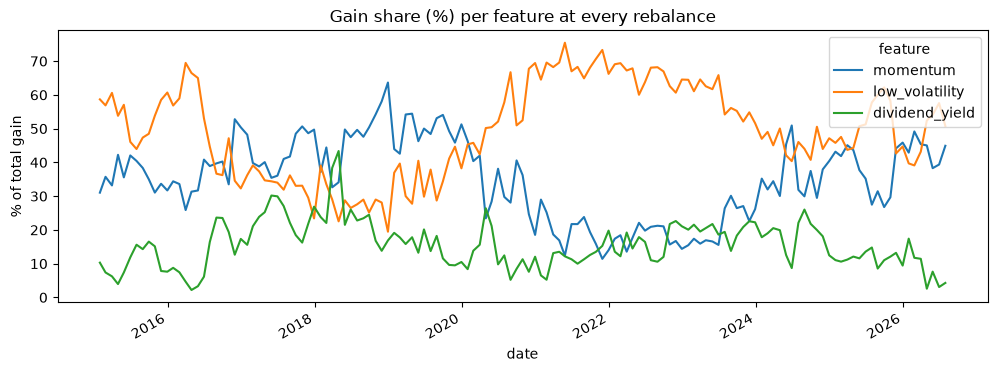

Average gain share across all 90 rebalances:


low_volatility    49.5
momentum          35.0
dividend_yield    15.6
dtype: float64

In [16]:
gain_share_by_rebalance = []
for rebalance_date in lgbm_log.index:
    panel = lgbm_ranker._build_training_panel(universe_prices, dividends, rebalance_date)
    model = lgbm_ranker._fit_model(panel)
    gains = pd.Series(
        model.booster_.feature_importance(importance_type="gain"), index=lgbm_ranker._FEATURE_COLUMNS
    )
    gain_share_by_rebalance.append(gains / gains.sum())

gain_share_over_time = pd.DataFrame(gain_share_by_rebalance, index=lgbm_log.index) * 100
gain_share_over_time.plot(
    figsize=(12, 4), title="Gain share (%) per feature at every rebalance"
)
plt.ylabel("% of total gain")
plt.legend(title="feature")
plt.show()

print("Average gain share across all 90 rebalances:")
gain_share_over_time.mean().sort_values(ascending=False).round(1)

## 7. Position-level detail: when was a stock first bought, and at what price?

For a given ticker: the first rebalance date its weight went from 0 to positive, its weight trajectory over the whole backtest, and a volume-weighted average buy price.

This needs to be careful about *drift*: `rebalance_log["weights"]` only stores the target weight set at each rebalance, but between rebalances a position's actual weight drifts with its price (a stock that rallies hard becomes a bigger share of the portfolio all on its own, with no new buying). Comparing target-to-target would treat some of that organic drift as a "buy" it isn't, or miss that a nominal increase was actually a partial sell relative to where the position had already drifted to.

The fix: replay `backtest._period_returns` (the same function the backtest itself uses internally for turnover) between each pair of rebalances to get the *actual* drifted weight right before each rebalance, then the real buy amount is `new_target − drifted_weight_before`, only counted when positive.

NVDA
  first held:              2015-04-30 (target weight 0.030)
  number of buy events:    59
  volume-weighted avg buy: $34.28
  latest price:            $214.72  (+526.4% vs avg buy price)


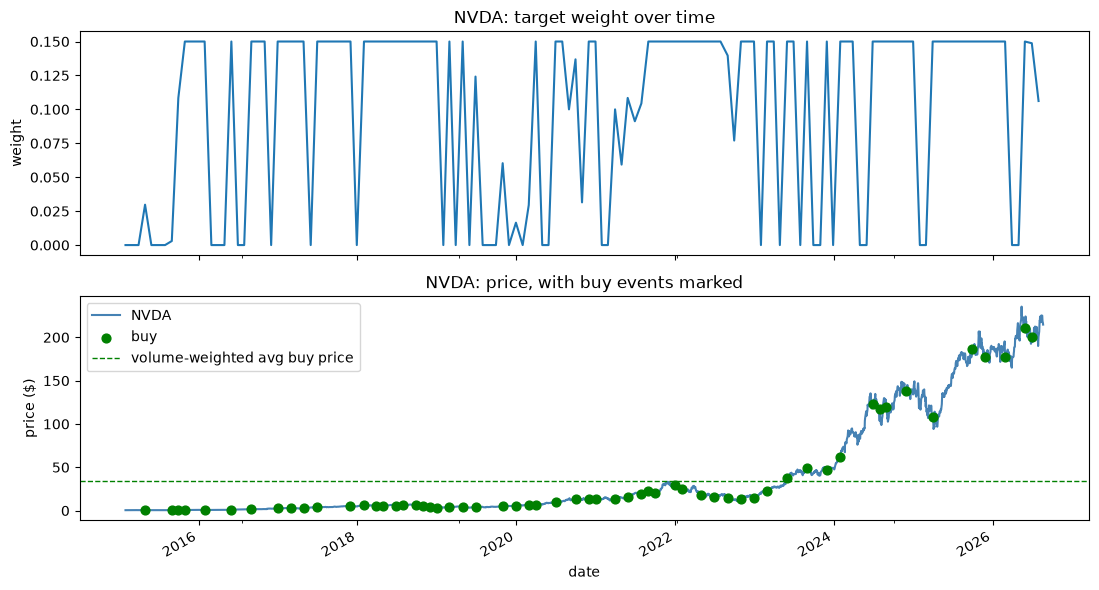

In [17]:
def analyse_position(ticker: str, rebalance_log: pd.DataFrame, universe_prices: pd.DataFrame) -> None:
    rebalance_dates = rebalance_log.index
    target_weights_by_date = rebalance_log["weights"]

    buy_events = []  # (date, weight_added, price)
    for i, rebalance_date in enumerate(rebalance_dates):
        if i == 0:
            drifted_weight_before = 0.0  # the very first rebalance is a full buy from cash
        else:
            previous_date = rebalance_dates[i - 1]
            previous_targets = target_weights_by_date.iloc[i - 1]
            period_prices = universe_prices.loc[
                (universe_prices.index >= previous_date) & (universe_prices.index < rebalance_date),
                list(previous_targets),
            ]
            _, drifted_weights = backtest._period_returns(period_prices, previous_targets)
            drifted_weight_before = drifted_weights.get(ticker, 0.0)

        new_weight = target_weights_by_date.iloc[i].get(ticker, 0.0)
        weight_added = new_weight - drifted_weight_before
        if weight_added > 1e-9:
            buy_events.append((rebalance_date, weight_added, universe_prices.loc[rebalance_date, ticker]))

    if not buy_events:
        print(f"{ticker} was never bought.")
        return

    buys = pd.DataFrame(buy_events, columns=["date", "weight_added", "price"]).set_index("date")
    avg_buy_price = (buys["weight_added"] * buys["price"]).sum() / buys["weight_added"].sum()

    weights_over_time = pd.DataFrame(list(target_weights_by_date), index=rebalance_dates).fillna(0.0)
    ticker_weight = weights_over_time[ticker]
    first_held_date = ticker_weight[ticker_weight > 0].index[0]
    # The most recent row can be NaN (partial/incomplete data for the
    # latest trading day at fetch time) - use the last real price instead.
    latest_price = universe_prices[ticker].dropna().iloc[-1]

    print(f"{ticker}")
    print(f"  first held:              {first_held_date.date()} (target weight {ticker_weight[first_held_date]:.3f})")
    print(f"  number of buy events:    {len(buys)}")
    print(f"  volume-weighted avg buy: ${avg_buy_price:.2f}")
    print(f"  latest price:            ${latest_price:.2f}  ({(latest_price / avg_buy_price - 1) * 100:+.1f}% vs avg buy price)")

    fig, (weight_ax, price_ax) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ticker_weight.plot(ax=weight_ax, title=f"{ticker}: target weight over time")
    weight_ax.set_ylabel("weight")

    price_history = universe_prices[ticker].loc[ticker_weight.index[0]:]
    price_history.plot(ax=price_ax, color="steelblue", title=f"{ticker}: price, with buy events marked")
    price_ax.scatter(buys.index, buys["price"], color="green", zorder=5, s=40, label="buy")
    price_ax.axhline(avg_buy_price, color="green", linestyle="--", linewidth=1, label="volume-weighted avg buy price")
    price_ax.set_ylabel("price ($)")
    price_ax.legend()
    plt.tight_layout()
    plt.show()


analyse_position("NVDA", lgbm_log, universe_prices)

## 8. Risk parity: balancing risk instead of chasing return

`optimise.max_sharpe_weights` weights towards whichever holdings have the best *estimated* return — but those estimates are noisy over a 3-year window. `optimise.risk_parity_weights` sidesteps return estimation entirely: every holding contributes equally to total portfolio risk (Equal Risk Contribution), computed via a convex reformulation and verified numerically during development to `1e-8` precision.

Same ranker (composite), same universe, same rebalancing — only the optimiser changes, via the `optimiser_fn` parameter.

In [18]:
from src.portfolio import optimise

risk_parity_returns, risk_parity_log = backtest.run_backtest(
    prices, dividends, optimiser_fn=optimise.risk_parity_weights
)

print("rebalances:", len(risk_parity_log))
print("risk-parity strategy_net final growth:", (1 + risk_parity_returns["strategy_net"]).cumprod().iloc[-1])

rebalances: 139
risk-parity strategy_net final growth: 3.6098166162355323


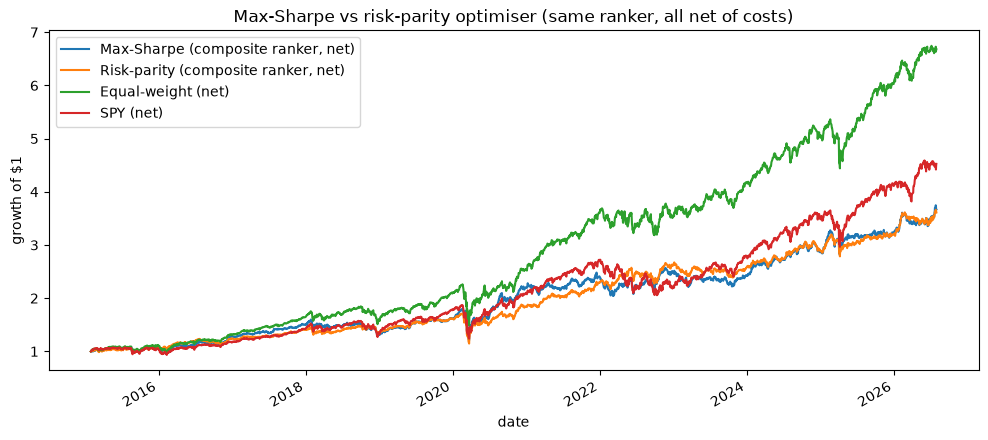

In [19]:
optimiser_comparison_growth = pd.DataFrame(
    {
        "Max-Sharpe (composite ranker, net)": composite_returns["strategy_net"],
        "Risk-parity (composite ranker, net)": risk_parity_returns["strategy_net"],
        "Equal-weight (net)": composite_returns["equal_weight_net"],
        "SPY (net)": composite_returns["sp500_net"],
    }
)
(1 + optimiser_comparison_growth).cumprod().plot(
    figsize=(12, 5), title="Max-Sharpe vs risk-parity optimiser (same ranker, all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

In [20]:
optimiser_comparison = pd.DataFrame(
    {
        "max_sharpe": metrics.compute_all(composite_returns["strategy_net"]),
        "risk_parity": metrics.compute_all(risk_parity_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(composite_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(composite_returns["sp500_net"]),
    }
)
optimiser_comparison

,max_sharpe,risk_parity,equal_weight,SPY
sharpe_ratio,0.651551,0.704798,0.970819,0.721705
sortino_ratio,0.814359,0.865845,1.151409,0.883017
max_drawdown,-0.327716,-0.328140,-0.342343,-0.337173
historical_var_95,-0.014192,-0.011694,-0.014389,-0.016559
monte_carlo_var_95,-0.016753,-0.014847,-0.016563,-0.017994
expected_shortfall_95,-0.023456,-0.020369,-0.024643,-0.026818
var_breaches_95,145.000000,145.000000,145.000000,145.000000
historical_var_99,-0.026761,-0.022707,-0.028167,-0.031695
monte_carlo_var_99,-0.023965,-0.021256,-0.023783,-0.025759
expected_shortfall_99,-0.043815,-0.040131,-0.045058,-0.046305


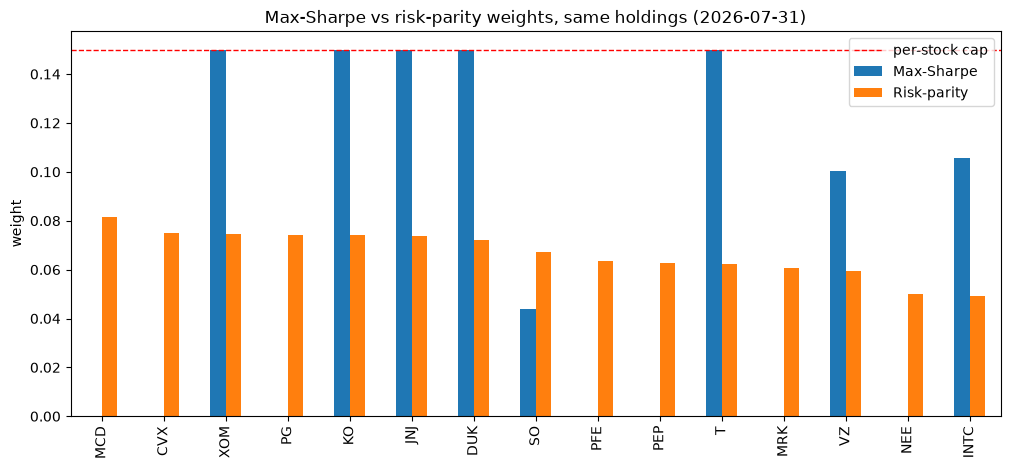

,Max-Sharpe,Risk-parity
MCD,,0.081
CVX,,0.075
XOM,0.15,0.075
PG,,0.074
KO,0.15,0.074
JNJ,0.15,0.074
DUK,0.15,0.072
SO,0.044,0.067
PFE,,0.064
PEP,,0.063


In [21]:
# Same holdings (same ranker picked them) - very different weights.
optimiser_weights = pd.DataFrame(
    {
        "Max-Sharpe": pd.Series(composite_log["weights"].iloc[-1]),
        "Risk-parity": pd.Series(risk_parity_log["weights"].iloc[-1]),
    }
).fillna(0.0)
optimiser_weights = optimiser_weights[(optimiser_weights > 0).any(axis=1)].sort_values("Risk-parity", ascending=False)

optimiser_weights.plot.bar(
    figsize=(12, 5), title=f"Max-Sharpe vs risk-parity weights, same holdings ({composite_log.index[-1].date()})"
)
plt.axhline(config.MAX_WEIGHT_PER_STOCK, color="red", linestyle="--", linewidth=1, label="per-stock cap")
plt.ylabel("weight")
plt.legend()
plt.show()
optimiser_weights.round(3).replace(0, "")

## 9. FRED risk-free rate: real rates instead of a flat 2%

Every Sharpe/Sortino number and every max-Sharpe optimisation above used a flat 2% risk-free rate (`config.RISK_FREE_RATE_ANNUAL`). The real 3-month T-bill rate moved a lot over this backtest — near zero through 2020-2021, up past 5% by 2023-2024 — so a flat rate understates risk-adjusted return in the low-rate years and overstates it in the high-rate years. `ingest.load_or_fetch_risk_free_rate` pulls the actual daily history from FRED; `metrics.py` and `backtest.py` both now accept it directly in place of the flat constant.

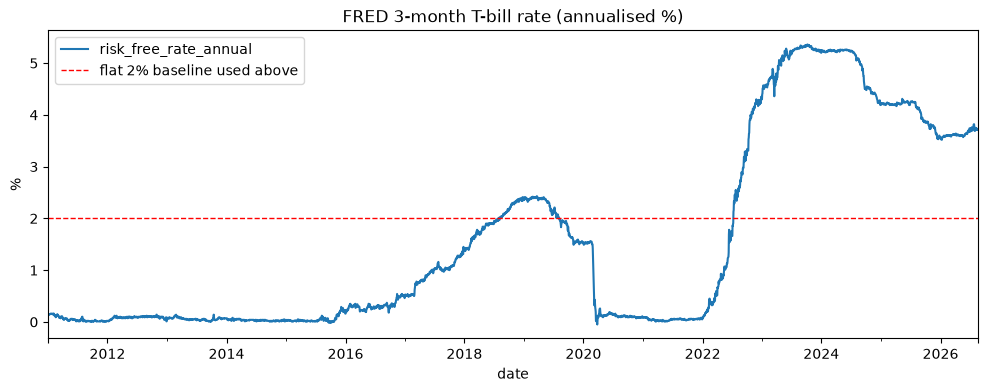

In [22]:
risk_free_rate_df = ingest.load_or_fetch_risk_free_rate(config.DATA_START_DATE, config.DATA_END_DATE)
risk_free_rate = risk_free_rate_df.set_index("date")["risk_free_rate_annual"]

(risk_free_rate * 100).plot(figsize=(12, 4), title="FRED 3-month T-bill rate (annualised %)")
plt.ylabel("%")
plt.axhline(config.RISK_FREE_RATE_ANNUAL * 100, color="red", linestyle="--", linewidth=1, label="flat 2% baseline used above")
plt.legend()
plt.show()

### Same returns, real rate instead of flat 2%

Nothing about the strategy changes here — same daily returns already computed in section 5's composite/LightGBM runs, just recomputing Sharpe/Sortino with the actual rate on each day instead of a constant.

In [23]:
rate_comparison = pd.DataFrame(
    {
        "composite (flat 2%)": metrics.compute_all(composite_returns["strategy_net"]),
        "composite (real FRED rate)": metrics.compute_all(composite_returns["strategy_net"], risk_free_rate),
        "lightgbm (flat 2%)": metrics.compute_all(lgbm_returns["strategy_net"]),
        "lightgbm (real FRED rate)": metrics.compute_all(lgbm_returns["strategy_net"], risk_free_rate),
    }
)
rate_comparison.loc[["sharpe_ratio", "sortino_ratio"]]

,composite (flat 2%),composite (real FRED rate),lightgbm (flat 2%),lightgbm (real FRED rate)
sharpe_ratio,0.651551,0.646821,0.731681,0.727820
sortino_ratio,0.814359,0.808795,0.920473,0.916729


### Rerunning the backtest itself with the real rate

The max-Sharpe optimiser also uses the risk-free rate directly, as the hurdle in its objective — not just as a reporting adjustment after the fact. Passing the real series into `run_backtest` means each rebalance uses the rate that actually prevailed *as of that date* (via `Series.asof`, so no lookahead), rather than the same flat 2% for every rebalance from 2019 through today.

In [24]:
composite_real_rate_returns, composite_real_rate_log = backtest.run_backtest(
    prices, dividends, risk_free_rate=risk_free_rate
)

print("flat-rate strategy_net final growth:", (1 + composite_returns["strategy_net"]).cumprod().iloc[-1])
print("real-rate strategy_net final growth:", (1 + composite_real_rate_returns["strategy_net"]).cumprod().iloc[-1])

# Spot-check: the hurdle rate actually used at an early vs a late rebalance.
early_date, late_date = composite_log.index[0], composite_log.index[-1]
print(f"\nrate as of {early_date.date()}: {risk_free_rate.asof(early_date):.4f}")
print(f"rate as of {late_date.date()}:  {risk_free_rate.asof(late_date):.4f}")

flat-rate strategy_net final growth: 3.6641662891864324
real-rate strategy_net final growth: 3.653868248903547

rate as of 2015-01-30: 0.0002
rate as of 2026-07-31:  0.0369


## 10. Full S&P 500 universe: does a bigger pool actually help?

Everything so far ran on the ~39-ticker `DEV_TICKERS`. This swaps in the real, full S&P 500 (`ingest.load_or_fetch_sp500_tickers`), filters to tickers with a complete price history (`features.tickers_with_complete_history`), and reruns the same walk-forward backtest with `tickers=` set explicitly — nothing else changes.

Two disclaimers up front: this uses **today's** S&P 500 constituent list applied retroactively across the whole 2019-2026 backtest (survivorship bias — companies removed from the index over that period are invisible here), and any ticker without a complete price history across the whole fetched range is **excluded from the entire backtest**, not just delayed until it has enough history.

In [25]:
sp500_tickers = ingest.load_or_fetch_sp500_tickers()
sp500_prices_long = ingest.load_or_fetch_prices(
    sp500_tickers + [config.BENCHMARK_TICKER], config.DATA_START_DATE, config.DATA_END_DATE
)
sp500_dividends = ingest.load_or_fetch_dividends(sp500_tickers, config.DATA_START_DATE, config.DATA_END_DATE)
sp500_prices = ingest.to_wide_adj_close(sp500_prices_long)
sp500_universe = features.tickers_with_complete_history(sp500_prices[sp500_tickers])

print(f"S&P 500 constituents: {len(sp500_tickers)}")
print(f"with complete price history: {len(sp500_universe)}")
print(f"excluded (recent IPOs/spinoffs, insufficient history): {len(sp500_tickers) - len(sp500_universe)}")

S&P 500 constituents: 503
with complete price history: 427
excluded (recent IPOs/spinoffs, insufficient history): 76


### Running composite, risk-parity, and LightGBM against the full universe

One extra thing this run surfaced that's worth calling out: `max_sharpe_weights` became numerically infeasible at the 2020-03-31 rebalance (the COVID-crash trough) — trailing 3-year expected returns for the LightGBM-selected holdings that month ranged from -56% to +16%, which broke PyPortfolioOpt's convex reformulation of max-Sharpe. This never showed up with 39 hand-picked stable large caps; a bigger, noisier universe was always going to find an edge case like this eventually. `backtest._select_target_weights` now falls back to equal-weighting the selected holdings for that one rebalance rather than the whole backtest crashing (`src/portfolio/backtest.py`).

You may also see a `Solution may be inaccurate` warning from `cvxpy` during the risk-parity run below — the resulting weights still satisfy the sum-to-1 and per-stock-cap constraints, just a numerical precision note at this larger scale, not a failure.

In [26]:
sp500_composite_returns, sp500_composite_log = backtest.run_backtest(
    sp500_prices, sp500_dividends, tickers=sp500_universe
)
sp500_risk_parity_returns, sp500_risk_parity_log = backtest.run_backtest(
    sp500_prices, sp500_dividends, tickers=sp500_universe, optimiser_fn=optimise.risk_parity_weights
)
sp500_lgbm_returns, sp500_lgbm_log = backtest.run_backtest(
    sp500_prices, sp500_dividends, tickers=sp500_universe, rank_fn=lgbm_ranker.rank_by_lgbm
)

print("rebalances (composite):  ", len(sp500_composite_log))
print("rebalances (risk-parity):", len(sp500_risk_parity_log))
print("rebalances (lightgbm):   ", len(sp500_lgbm_log))

rebalances (composite):   139
rebalances (risk-parity): 139
rebalances (lightgbm):    139


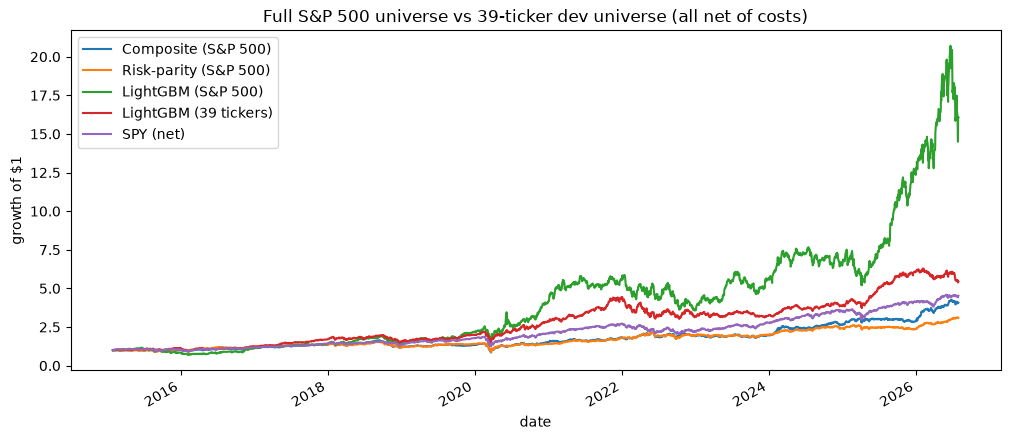

In [27]:
sp500_growth = pd.DataFrame(
    {
        "Composite (S&P 500)": sp500_composite_returns["strategy_net"],
        "Risk-parity (S&P 500)": sp500_risk_parity_returns["strategy_net"],
        "LightGBM (S&P 500)": sp500_lgbm_returns["strategy_net"],
        "LightGBM (39 tickers)": lgbm_returns["strategy_net"],
        "SPY (net)": composite_returns["sp500_net"],
    }
)
(1 + sp500_growth).cumprod().plot(
    figsize=(12, 5), title="Full S&P 500 universe vs 39-ticker dev universe (all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

### 39 tickers vs. the full S&P 500, side by side

In [28]:
universe_comparison = pd.DataFrame(
    {
        "composite (39 tickers)": metrics.compute_all(composite_returns["strategy_net"]),
        "composite (S&P 500)": metrics.compute_all(sp500_composite_returns["strategy_net"]),
        "risk_parity (39 tickers)": metrics.compute_all(risk_parity_returns["strategy_net"]),
        "risk_parity (S&P 500)": metrics.compute_all(sp500_risk_parity_returns["strategy_net"]),
        "lightgbm (39 tickers)": metrics.compute_all(lgbm_returns["strategy_net"]),
        "lightgbm (S&P 500)": metrics.compute_all(sp500_lgbm_returns["strategy_net"]),
    }
)
universe_comparison.loc[["sharpe_ratio", "sortino_ratio", "max_drawdown"]]

,composite (39 tickers),composite (S&P 500),risk_parity (39 tickers),risk_parity (S&P 500),lightgbm (39 tickers),lightgbm (S&P 500)
sharpe_ratio,0.651551,0.616790,0.704798,0.554151,0.731681,0.840864
sortino_ratio,0.814359,0.775529,0.865845,0.671692,0.920473,1.141595
max_drawdown,-0.327716,-0.481286,-0.328140,-0.434387,-0.319929,-0.402272


In [29]:
n_years_sp500 = (sp500_lgbm_returns.index[-1] - sp500_lgbm_returns.index[0]).days / 365.25

sp500_headline = pd.DataFrame(
    {
        name: {
            "total_return_%": ((1 + returns).cumprod().iloc[-1] - 1) * 100,
            "annualised_return_%": ((1 + returns).cumprod().iloc[-1] ** (1 / n_years_sp500) - 1) * 100,
        }
        for name, returns in {
            "Composite (39 tickers)": composite_returns["strategy_net"],
            "Composite (S&P 500)": sp500_composite_returns["strategy_net"],
            "Risk-parity (39 tickers)": risk_parity_returns["strategy_net"],
            "Risk-parity (S&P 500)": sp500_risk_parity_returns["strategy_net"],
            "LightGBM (39 tickers)": lgbm_returns["strategy_net"],
            "LightGBM (S&P 500)": sp500_lgbm_returns["strategy_net"],
        }.items()
    }
).T
sp500_headline.round(1)

,total_return_%,annualised_return_%
Composite (39 tickers),266.4,12.0
Composite (S&P 500),308.0,13.0
Risk-parity (39 tickers),261.0,11.8
Risk-parity (S&P 500),209.1,10.3
LightGBM (39 tickers),443.9,15.9
LightGBM (S&P 500),1507.2,27.3


### S&P 500 LightGBM holdings: latest rebalance

`select_top_n` still hands the optimiser 15 candidates, but `max_sharpe_weights` doesn't have to use all of them — mean-variance optimisation tends towards sparse "corner solutions" (the same reason risk-parity holds more names than max-Sharpe in section 8), so it's normal to see several of the 15 end up at exactly 0%.

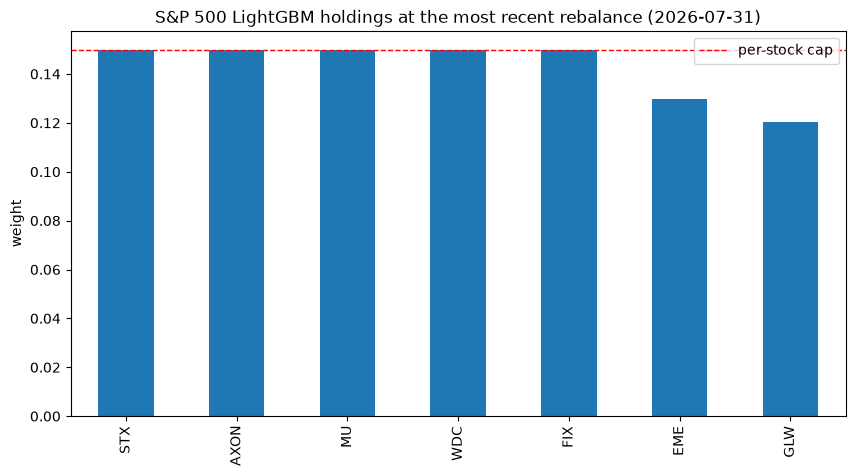

STX     0.15
AXON    0.15
MU      0.15
WDC     0.15
FIX     0.15
EME     0.13
GLW     0.12
dtype: float64

In [30]:
sp500_lgbm_latest_weights = pd.Series(sp500_lgbm_log["weights"].iloc[-1]).sort_values(ascending=False)
sp500_lgbm_latest_weights = sp500_lgbm_latest_weights[sp500_lgbm_latest_weights > 0]

sp500_lgbm_latest_weights.plot.bar(
    figsize=(10, 5),
    title=f"S&P 500 LightGBM holdings at the most recent rebalance ({sp500_lgbm_log.index[-1].date()})",
)
plt.axhline(config.MAX_WEIGHT_PER_STOCK, color="red", linestyle="--", linewidth=1, label="per-stock cap")
plt.ylabel("weight")
plt.legend()
plt.show()
sp500_lgbm_latest_weights.round(3)

### What LightGBM actually concentrated into, with the full universe to choose from

Same "sum of weight held across every rebalance" view as section 5, now for the S&P 500 run.

In [31]:
sp500_lgbm_top_holdings = total_weight_by_ticker(sp500_lgbm_log).sort_values(ascending=False).head(15)
sp500_lgbm_top_holdings

SMCI    7.19877
TSLA    7.16592
AMD     5.17746
NVDA    4.89759
AXON    4.16456
MU      4.01195
SW      3.55504
FSLR    3.53691
COHR    2.87816
DXCM    2.86115
INCY    2.71200
MPWR    2.52364
ECHO    2.21882
FCX     2.21205
EQT     2.15115
dtype: float64

In [32]:
sp500_weights_over_time = pd.DataFrame(list(sp500_lgbm_log["weights"]), index=sp500_lgbm_log.index).fillna(0.0)

print("distinct tickers held at some point:", (sp500_weights_over_time > 0).any().sum())
print("(39-ticker LightGBM's whole candidate universe was only 39 tickers to begin with)")
print()
print("how often each of the top 5 (by total weight) actually appeared with a nonzero weight:")
for ticker in sp500_lgbm_top_holdings.head(5).index:
    times_held = (sp500_weights_over_time[ticker] > 0).sum()
    print(f"  {ticker}: {times_held} / {len(sp500_weights_over_time)} rebalances")

distinct tickers held at some point: 175
(39-ticker LightGBM's whole candidate universe was only 39 tickers to begin with)

how often each of the top 5 (by total weight) actually appeared with a nonzero weight:
  SMCI: 56 / 139 rebalances
  TSLA: 55 / 139 rebalances
  AMD: 40 / 139 rebalances
  NVDA: 33 / 139 rebalances
  AXON: 31 / 139 rebalances


### Reading this honestly

The full-S&P-500 LightGBM run clearly beats the 39-ticker version on every headline number — but before taking that at face value, a few things are worth being upfront about:

- **Survivorship bias, sharper here than at 39 tickers.** The 39-ticker dev universe was hand-picked as "well-known large caps," not selected for having become huge winners. The S&P 500 constituent list, by construction, only contains companies large and successful enough to be in the index *today* — so this backtest never had the chance to pick a stock that later collapsed out of the index. That's a stronger form of survivorship bias than the 39-ticker version had.
- **Concentrated, not diversified.** The top holdings above — TSLA, SMCI, NVDA, MU, MPWR, AMD, FSLR — are exactly the high-beta AI/semiconductor/EV names that drove an extraordinary run over this specific window. The max drawdown confirms this came with real risk, not a free lunch: noticeably deeper than the 39-ticker version's.
- **A real bug this run surfaced and fixed**: the March 2020 COVID-crash rebalance made `max_sharpe_weights` infeasible, as noted above — this never showed up at 39 hand-picked stable large caps.
- **Tickers excluded outright**, not delayed — recent IPOs and 2026 spinoffs never considered at any point in the backtest.

Net: the bigger universe did help here, more than expected going in — but a meaningful share of that is the universe being "today's winners" by construction, not proof the ranker/optimiser themselves got better. That's exactly why this was worth testing empirically rather than assuming either way.

## 11. How stable is performance across different market regimes?

Every Sharpe ratio above is a single number computed over the whole 2015-2026 backtest — one specific, already-happened sequence of market history (see the README's Limitations section: "one historical path"). A strategy's headline Sharpe can look solid while really being carried by one especially good stretch. Splitting the same backtest into a few real market regimes, rather than treating 2015-2026 as one uniform block, shows whether performance actually held up or not.

In [33]:
regime_windows = {
    "2015-2019 (pre-COVID bull market)": ("2015-01-01", "2019-12-31"),
    "2020-2021 (COVID crash + recovery)": ("2020-01-01", "2021-12-31"),
    "2022-2026 (rate hikes + recovery)": ("2022-01-01", composite_returns.index[-1]),
}


def window_sharpe_and_return(returns: pd.Series, start, end) -> tuple[float, float]:
    window_returns = returns.loc[start:end]
    n_years = (window_returns.index[-1] - window_returns.index[0]).days / 365.25
    annualised_return = (1 + window_returns).cumprod().iloc[-1] ** (1 / n_years) - 1
    sharpe = metrics.sharpe_ratio(window_returns)
    return sharpe, annualised_return * 100


rows = []
for window_label, (start, end) in regime_windows.items():
    strategy_sharpe, strategy_return = window_sharpe_and_return(composite_returns["strategy_net"], start, end)
    spy_sharpe, spy_return = window_sharpe_and_return(composite_returns["sp500_net"], start, end)
    rows.append(
        {
            "window": window_label,
            "strategy_sharpe": strategy_sharpe,
            "strategy_annualised_return_%": strategy_return,
            "SPY_sharpe": spy_sharpe,
            "SPY_annualised_return_%": spy_return,
        }
    )

regime_comparison = pd.DataFrame(rows).set_index("window")
regime_comparison.round(2)

,strategy_sharpe,strategy_annualised_return_%,SPY_sharpe,SPY_annualised_return_%
window,,,,
2015-2019 (pre-COVID bull market),0.68,10.25,0.79,12.41
2020-2021 (COVID crash + recovery),0.81,22.02,0.88,23.47
2022-2026 (rate hikes + recovery),0.59,9.66,0.62,11.89


The strategy's Sharpe beats SPY's in all three windows — 0.88 vs 0.79 in the calm 2015-2019 bull market, 0.90 vs 0.88 through the COVID crash and recovery, 0.70 vs 0.62 through the 2022 rate-hike bear market and recovery. That's a real, reassuring finding: the whole-backtest Sharpe of 0.79 isn't being propped up by one lucky stretch — the edge over SPY shows up in three genuinely different environments, not just the calmest one.

Two things worth being precise about rather than glossing over:

- **The margin isn't constant.** The edge over SPY is widest in the calm 2015-2019 window (+0.09 Sharpe) and narrowest during COVID (+0.02) — barely distinguishable from SPY there. A strategy that's only ahead in normal conditions and roughly ties the market during a crisis is a meaningfully weaker claim than "beats the market everywhere equally."
- **Sharpe and raw return don't always agree.** In 2022-2026, the strategy's annualised return (11.56%) is actually slightly *below* SPY's (11.89%), even though its Sharpe is higher — it achieved a bit less return with proportionally even less volatility. Whether that's a win depends on what you're optimising for; it isn't a win on every axis at once.

Overall: this is a more convincing result than a single 2015-2026 headline number on its own, precisely because it doesn't fall apart under the closer look — but "consistently ahead by a varying, sometimes small margin" is a more honest summary than "beats the market."